# H2 — Mental-model Accuracy / Explicability (F1 / F2 / F3)

OpenMATB transparency study (content-constant, *wording-only* design). This
notebook covers **only hypothesis H2** — one half of the load-bearing H1/H2 pair
— as stated in the report (`Documents/Report/main.tex`, §3 and the *H2 —
Mental-model probe* measure):

> **H2 (contrastive form improves explicability).** Post-block mental-model
> accuracy is highest under the contrastive forms **F2 / F3**, even though the
> information content is identical across forms.

H2 is the **objective** counterpart to H1: where H1 asks whether the verbose form
*feels* more transparent (subjective explainability), H2 asks whether the
operator's mental model actually *updated* (objective explicability). The study's
core claim is that these move in **opposite** directions — F1 feels most
informative, yet F2/F3 leave the operator better calibrated.

**Design (from the study, see `project_3_study.pdf`).**

| Role | Variable | Detail |
|------|----------|--------|
| Independent variable | Explanation **form** | F1 verbose · F2 contrastive · F3 contrastive + actionable. **Within-subjects** — each participant sees all three (Latin-square counterbalanced), each paired with a different gauge set (A/B/C) so the probe cannot be answered from another block. |
| Primary DV | **Explicability composite** | `mm_explicability` ∈ [0, 1], the mean of the available probe sub-scores. Higher = better-calibrated mental model. |
| Sub-scores | recognition + calibration | recognition accuracy (higher = better); miss-count / close-call-count / reliability **errors** vs. ground truth (lower = better). |

## How H2 is measured (the mental-model probe)

After each block — *before* the subjective items, to capture the model before
reflection contaminates it — five `genericscales` sliders probe the operator's
mental model, scored **offline against that block's ground truth** (2 misses,
2 near-misses, ~78 % reliability):

- **Calibration (3 items).** "How often did the aid *fail to act*?", "…step in
  *just in time*?", "Overall, how *reliable* was the aid?" Scored as the absolute
  deviation of the slider from truth (`mm_misses_error`, `mm_closecalls_error`,
  `mm_reliability_error`); **lower = better**.
- **Recognition (2 items).** "Did the aid act on Scale X / Light Y?" Truth is
  whether that indicator is in the block's set. Scored as the proportion answered
  on the correct side (`mm_rec_accuracy`); **higher = better**.

The composite `mm_explicability` normalises each calibration error to a [0, 1]
accuracy and averages it with the recognition accuracy, so a single number per
block captures overall mental-model quality. (Scoring lives in
`matb_analysis/metrics_questionnaire.py`.)

We report **descriptive statistics and visualisations**; the closing section
states the statistical approach and the test that applies to this design.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matb_analysis.aggregate import build_metrics_table
from matb_analysis.discovery import find_study_sessions, DEFAULT_SESSIONS_DIR
from matb_analysis.validation import validate_sessions

sns.set_theme(style="whitegrid")
FORM_ORDER = ["F1", "F2", "F3"]
FORM_LABELS = {"F1": "F1\nverbose", "F2": "F2\ncontrastive", "F3": "F3\n+actionable"}
OUT = Path.cwd().parent / "outputs"
OUT.mkdir(exist_ok=True)

# Analyse the full simulated cohort (N=20, known ground truth); fall back to the
# default session_logs once real participants are collected. Whichever directory
# actually contains study sessions is used.
CANDIDATES = [Path.cwd().parent / "simulated", DEFAULT_SESSIONS_DIR]
DATA_DIR = next((d for d in CANDIDATES if find_study_sessions(d)), CANDIDATES[0])

## 1. Load the sessions and build the H2 metrics table

`find_study_sessions()` reads every study session under `DATA_DIR`. Each session
contributes three rows (one per form). The mental-model metrics are produced by
`build_metrics_table()`, which scores the five probe sliders against each block's
ground truth.

In [2]:
sessions = find_study_sessions(DATA_DIR)
print(f"Reading logs from: {DATA_DIR}")
print(f"Discovered {len(sessions)} study session(s).")

table = build_metrics_table(sessions)
H2_COLS = ["mm_explicability", "mm_rec_accuracy", "mm_misses_error",
           "mm_closecalls_error", "mm_reliability_error"]
(table[["participant", "form", "block"] + H2_COLS]
    .sort_values(["participant", "form"]).reset_index(drop=True))

Reading logs from: C:\Projects\HumanCenteredAI\analysis\simulated
Discovered 20 study session(s).


,participant,form,block,mm_explicability,mm_rec_accuracy,mm_misses_error,mm_closecalls_error,mm_reliability_error
0,P01,F1,A,0.719729,0.5,1.204987,1.142611,22.222222
1,P01,F2,B,0.922647,1.0,1.242748,0.216014,7.856924
2,P01,F3,C,0.754460,0.5,1.412056,1.301246,7.353439
3,P02,F1,A,0.851519,1.0,1.436210,2.000000,8.014039
4,P02,F2,C,0.892344,1.0,0.155145,2.012874,9.403915
5,P02,F3,B,0.898949,1.0,0.892767,0.521294,15.726442
6,P03,F1,B,0.663084,0.5,1.883839,2.049808,22.222222
7,P03,F2,A,0.900659,1.0,0.930463,0.543208,14.532077
8,P03,F3,C,0.826236,0.5,0.093743,1.215071,0.628598
9,P04,F1,C,0.795780,0.5,1.306665,0.059002,9.472063


### 1b. Sanity check: design realised as intended

Each session is cross-checked against the Latin-square design (form ↔ block order,
panel form vs. briefing). Every participant should contribute exactly one block per
form, so that each form is probed against all three gauge sets equally across the
cohort. Any `ok = False` row must be resolved before trusting that session.

In [3]:
report = validate_sessions(sessions)
n_bad = int((~report["ok"]).sum()) if not report.empty else 0
print(f"{len(report)} session(s) validated; {n_bad} with design issues.")

print(f"\nParticipants: {table['participant'].nunique()}")
print("Blocks per form (should be equal):")
print(table["form"].value_counts().reindex(FORM_ORDER).to_string())
print("\nform x gauge-set (counterbalancing):")
print(pd.crosstab(table["form"], table["block"]).reindex(FORM_ORDER).to_string())

20 session(s) validated; 0 with design issues.

Participants: 20
Blocks per form (should be equal):
form
F1    20
F2    20
F3    20

form x gauge-set (counterbalancing):
block  A  B  C
form          
F1     6  6  8
F2     8  6  6
F3     6  8  6


## 2. Primary DV — explicability composite by form

Descriptive statistics of `mm_explicability` (the [0, 1] composite, higher = a
more accurate mental model) for each form. H2 predicts the contrastive forms
**F2 / F3** to sit **above** the verbose form F1.

In [4]:
def describe(df, col):
    g = df.groupby("form")[col]
    out = pd.DataFrame({
        "n_blocks": g.size(),
        "mean": g.mean(),
        "sd": g.std(),
        "median": g.median(),
        "min": g.min(),
        "max": g.max(),
    }).reindex(FORM_ORDER).round(3)
    return out

describe(table, "mm_explicability")

,n_blocks,mean,sd,median,min,max
form,,,,,,
F1,20,0.727,0.094,0.725,0.556,0.857
F2,20,0.898,0.060,0.915,0.730,0.955
F3,20,0.885,0.054,0.906,0.754,0.944


**Figure 1 — distribution of the explicability composite by form.** Box = median
and interquartile range; whiskers = range; each dot is one block. H2 predicts the
F2/F3 distributions to sit above F1 (higher = better-calibrated mental model).

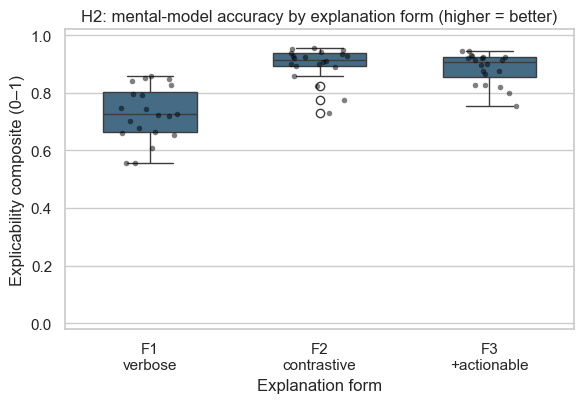

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.2))
sns.boxplot(data=table, x="form", y="mm_explicability", order=FORM_ORDER,
            color="#3b6e8f", width=0.55, ax=ax)
sns.stripplot(data=table, x="form", y="mm_explicability", order=FORM_ORDER,
              color="black", alpha=0.5, size=4, jitter=0.18, ax=ax)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("Explanation form")
ax.set_ylabel("Explicability composite (0–1)")
ax.set_xticks(range(len(FORM_ORDER)))
ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
ax.set_title("H2: mental-model accuracy by explanation form (higher = better)")
fig.tight_layout()
fig.savefig(OUT / "h2_explicability_by_form.png", dpi=150)
plt.show()

**Figure 2 — within-subject view.** Each grey line is one participant across the
three forms; the thick line is the mean. Because the design is within-subjects,
this shows whether *individuals* tend to build a more accurate model under F2/F3,
not just the group average.

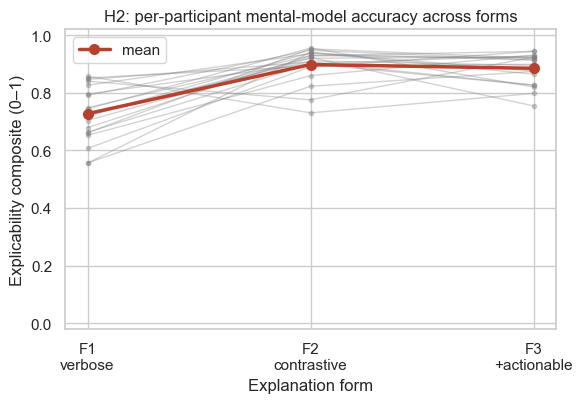

In [6]:
wide = table.pivot_table(index="participant", columns="form", values="mm_explicability")
wide = wide.reindex(columns=FORM_ORDER)

fig, ax = plt.subplots(figsize=(6, 4.2))
x = np.arange(len(FORM_ORDER))
for _, row in wide.iterrows():
    ax.plot(x, row.values, color="grey", alpha=0.35, marker="o", markersize=3,
            linewidth=1)
ax.plot(x, wide.mean(axis=0).values, color="#b8412e", marker="o", markersize=7,
        linewidth=2.5, label="mean")
ax.set_xticks(x)
ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("Explanation form")
ax.set_ylabel("Explicability composite (0–1)")
ax.set_title("H2: per-participant mental-model accuracy across forms")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "h2_explicability_perparticipant.png", dpi=150)
plt.show()

## 3. Unpacking the composite — recognition and calibration sub-scores

The composite combines two kinds of probe. This section reports each part
separately so an effect can be traced to its source: a sharper *recognition* of
which indicators the aid touched, and/or better-*calibrated* counts of the aid's
error profile.

- `mm_rec_accuracy` — proportion of the two recognition items correct (**higher = better**).
- `mm_misses_error`, `mm_closecalls_error` — absolute deviation of the count
  sliders from the truth of 2 each (**lower = better**).
- `mm_reliability_error` — absolute deviation from the true ~78 % (**lower = better**).

In [7]:
parts_desc = (table.groupby("form")[["mm_rec_accuracy", "mm_misses_error",
                                     "mm_closecalls_error", "mm_reliability_error"]]
                   .agg(["mean", "median", "std"])
                   .reindex(FORM_ORDER)
                   .round(3))
parts_desc

mm_rec_accuracy               mm_misses_error                \
                mean median    std            mean median    std   
form                                                               
F1             0.600    0.5  0.308           1.676  1.942  0.441   
F2             0.925    1.0  0.183           0.969  0.792  0.657   
F3             0.875    1.0  0.222           0.565  0.490  0.437   

     mm_closecalls_error               mm_reliability_error                  
                    mean median    std                 mean  median     std  
form                                                                         
F1                 1.647  1.741  1.174               16.778  15.730  11.024  
F2                 0.782  0.667  0.552                6.444   5.852   5.436  
F3                 0.968  0.926  0.538                9.042   7.383   6.950

**Figure 3 — the four sub-scores by form.** Recognition accuracy (top-left,
higher = better) and the three calibration errors (lower = better). H2 predicts
F2/F3 to sit **above** F1 on recognition and **below** F1 on every error.

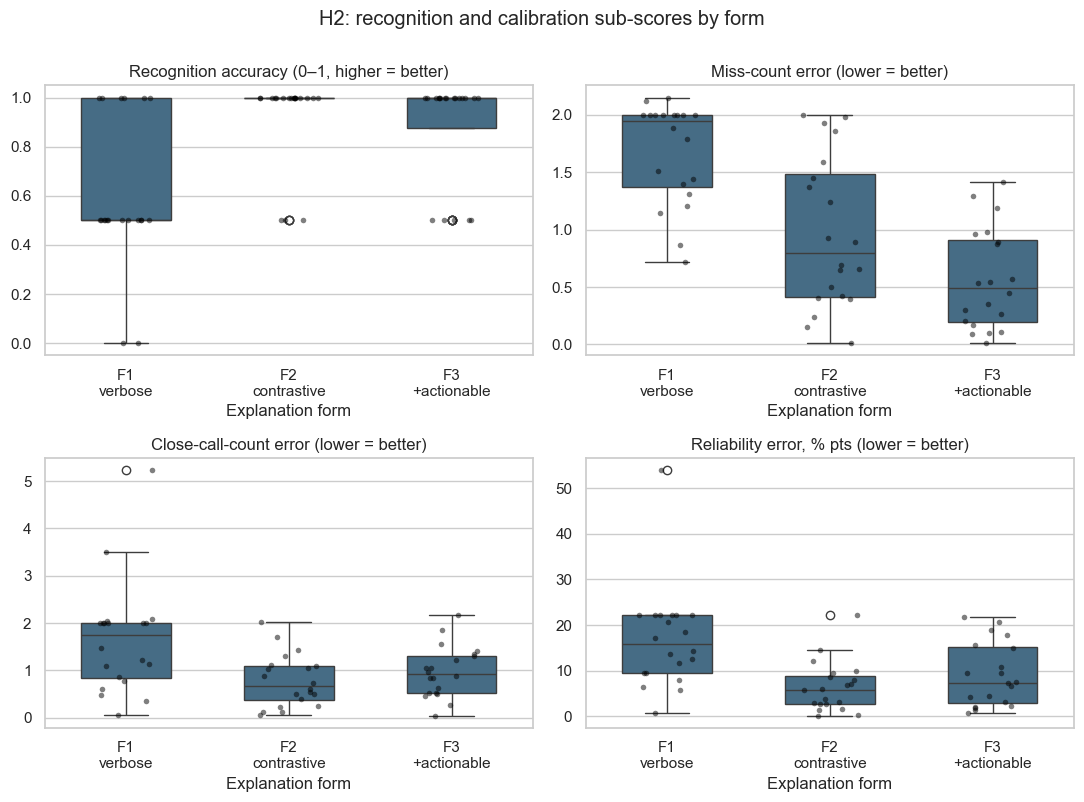

In [8]:
panels = [
    ("mm_rec_accuracy", "Recognition accuracy (0–1, higher = better)"),
    ("mm_misses_error", "Miss-count error (lower = better)"),
    ("mm_closecalls_error", "Close-call-count error (lower = better)"),
    ("mm_reliability_error", "Reliability error, % pts (lower = better)"),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (col, title) in zip(axes.ravel(), panels):
    sns.boxplot(data=table, x="form", y=col, order=FORM_ORDER,
                color="#3b6e8f", width=0.55, ax=ax)
    sns.stripplot(data=table, x="form", y=col, order=FORM_ORDER,
                  color="black", alpha=0.5, size=4, jitter=0.18, ax=ax)
    ax.set_xlabel("Explanation form")
    ax.set_ylabel("")
    ax.set_xticks(range(len(FORM_ORDER)))
    ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
    ax.set_title(title)
fig.suptitle("H2: recognition and calibration sub-scores by form", y=1.0)
fig.tight_layout()
fig.savefig(OUT / "h2_mentalmodel_by_form.png", dpi=150)
plt.show()

## 4. Compact summary table

One row per form, suitable for the report. H2 predicts the explicability composite
and recognition accuracy to **rise**, and the three calibration errors to **fall**,
from F1 to F2/F3.

In [9]:
SUMMARY_COLS = ["mm_explicability", "mm_rec_accuracy", "mm_misses_error",
                "mm_closecalls_error", "mm_reliability_error"]
summary = (table.groupby("form")[SUMMARY_COLS]
              .agg(["mean", "median", "std"])
              .reindex(FORM_ORDER)
              .round(3))
summary.to_csv(OUT / "h2_mental_model_summary_by_form.csv")
summary

mm_explicability               mm_rec_accuracy                \
                 mean median    std            mean median    std   
form                                                                
F1              0.727  0.725  0.094           0.600    0.5  0.308   
F2              0.898  0.915  0.060           0.925    1.0  0.183   
F3              0.885  0.906  0.054           0.875    1.0  0.222   

     mm_misses_error               mm_closecalls_error                \
                mean median    std                mean median    std   
form                                                                   
F1             1.676  1.942  0.441               1.647  1.741  1.174   
F2             0.969  0.792  0.657               0.782  0.667  0.552   
F3             0.565  0.490  0.437               0.968  0.926  0.538   

     mm_reliability_error                  
                     mean  median     std  
form                                       
F1                 16.778  15.730  11.024  
F2                  6.444   5.852   5.436  
F3                  9.042   7.383   6.950

## 5. Statistical analysis — descriptive focus

We report **descriptive statistics and visualisations** rather than a single
significance test, for two reasons tied to the measure and the study brief:

1. **Bounded, coarse sub-scores.** The probe yields a five-item composite built
   from a few coarse sliders per block; the means, medians, per-participant
   trajectories (Fig. 2) and sub-score breakdown (Fig. 3) convey the pattern more
   faithfully than a single test statistic would at this sample size.
2. **Deliberate, transparent inference.** The study brief cautions against
   over-interpreting modest sample sizes and against using unfamiliar tests, so we
   keep the inferential step explicit rather than reflexive.

**The test that fits this design.** Because the design is within-subjects with
three related conditions, the appropriate approach is a **repeated-measures ANOVA**
on the explicability composite (with sphericity checked) when it is approximately
normal, or a non-parametric **Friedman** omnibus followed by **Wilcoxon
signed-rank** post-hoc tests for the two planned, directional contrasts —
**F1 < F2** (contrastiveness) and **F2 < F3** (actionability) — with a Holm
correction and a rank-biserial effect size. The decisive test of the study's
thesis is the **H1 × H2 crossover**: a form × measure-type interaction on the
z-scored subjective-transparency (H1) and explicability (H2) scores, predicted to
run in *opposite* directions. The tidy table built above is the ready input for
that step.